# OnePen Model Analysis

This notebook analyzes the trained model performance on the exact same train/val/test split used during training.

**Key Point**: Using the same `random_state=42` ensures reproducible, identical splits.

In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

# Set style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

c:\Users\huybh\OneDrive\Documents\OnePen\.venv\Lib\site-packages\keras\src\export\tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


## 1. Configuration

These values must match `config/config.yaml` exactly to reproduce the training split.

In [2]:
# Configuration - MUST match training config
CONFIG = {
    'test_size': 0.10,
    'val_size': 0.16,
    'random_state': 42,  # Same as training for reproducibility
}

CLASS_NAMES = [
    'underline', 'box', 'curly', 'delete',
    'boxshortcut', 'curlyshortcut', 'circleshortcut', 'none'
]

# Paths
PROJECT_ROOT = Path.cwd().parent
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
MODEL_PATH = PROJECT_ROOT / 'outputs' / 'run_20260112_231257' / 'checkpoints' / 'best_model.keras'

print(f'Project root: {PROJECT_ROOT}')
print(f'Model path: {MODEL_PATH}')
print(f'Model exists: {MODEL_PATH.exists()}')

Project root: c:\Users\huybh\onedrive\documents\onepen
Model path: c:\Users\huybh\onedrive\documents\onepen\outputs\run_20260112_231257\checkpoints\best_model.keras
Model exists: True


## 2. Load Processed Data & Model

In [3]:
# Load processed data
data_file = PROCESSED_DIR / 'latest.npz'
if not data_file.exists():
    # Fall back to finding most recent
    data_file = sorted(PROCESSED_DIR.glob('processed_data_*.npz'), key=lambda p: p.stat().st_mtime)[-1]

print(f'Loading data from: {data_file}')
data = np.load(data_file)

images = data['images']
features = data['features']
labels = data['labels']

print(f'Images shape: {images.shape}')
print(f'Features shape: {features.shape}')
print(f'Labels shape: {labels.shape}')
print(f'Total samples: {len(labels)}')

Loading data from: c:\Users\huybh\onedrive\documents\onepen\data\processed\latest.npz
Images shape: (42614, 136, 136, 3)
Features shape: (42614, 10)
Labels shape: (42614,)
Total samples: 42614


In [4]:
# Load trained model
model = tf.keras.models.load_model(str(MODEL_PATH))
print(f'Model loaded successfully!')
print(f'Model inputs: {[inp.name for inp in model.inputs]}')

Model loaded successfully!
Model inputs: ['img_input', 'feature_input']


## 3. Split Data (Same as Training)

Using the exact same split parameters ensures we're evaluating on the same samples as during training.

In [5]:
def split_data(images, labels, features, test_size, val_size, random_state):
    """Split data identically to training."""
    n_samples = len(labels)
    indices = np.arange(n_samples)
    
    # First split: train+val vs test
    idx_trainval, idx_test = train_test_split(
        indices,
        test_size=test_size,
        stratify=labels,
        random_state=random_state,
    )
    
    # Second split: train vs val
    idx_train, idx_val = train_test_split(
        idx_trainval,
        test_size=val_size,
        stratify=labels[idx_trainval],
        random_state=random_state,
    )
    
    return {
        'X_train_img': images[idx_train], 'X_train_feat': features[idx_train], 'y_train': labels[idx_train],
        'X_val_img': images[idx_val], 'X_val_feat': features[idx_val], 'y_val': labels[idx_val],
        'X_test_img': images[idx_test], 'X_test_feat': features[idx_test], 'y_test': labels[idx_test],
        'idx_train': idx_train, 'idx_val': idx_val, 'idx_test': idx_test,
    }

splits = split_data(
    images, labels, features,
    CONFIG['test_size'], CONFIG['val_size'], CONFIG['random_state']
)

print(f"Train samples: {len(splits['y_train'])}")
print(f"Val samples: {len(splits['y_val'])}")
print(f"Test samples: {len(splits['y_test'])}")

Train samples: 32215
Val samples: 6137
Test samples: 4262


## 4. Evaluate on Train / Val / Test Sets

In [6]:
def predict_and_evaluate(model, X_img, X_feat, y_true, set_name):
    """Make predictions and compute accuracy."""
    y_pred_probs = model.predict(
        {'img_input': X_img, 'feature_input': X_feat},
        verbose=0
    )
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true_int = y_true.astype(int)
    
    accuracy = accuracy_score(y_true_int, y_pred)
    print(f'{set_name} Accuracy: {accuracy:.4f} ({accuracy*100:.2f}%)')
    
    return y_pred, y_pred_probs

print('=' * 50)
print('Model Accuracy on Each Split')
print('=' * 50)

y_train_pred, _ = predict_and_evaluate(
    model, splits['X_train_img'], splits['X_train_feat'], splits['y_train'], 'Train'
)

y_val_pred, _ = predict_and_evaluate(
    model, splits['X_val_img'], splits['X_val_feat'], splits['y_val'], 'Val'
)

y_test_pred, y_test_probs = predict_and_evaluate(
    model, splits['X_test_img'], splits['X_test_feat'], splits['y_test'], 'Test'
)

Model Accuracy on Each Split
Train Accuracy: 0.9888 (98.88%)
Val Accuracy: 0.9835 (98.35%)
Test Accuracy: 0.9826 (98.26%)


## 5. Confusion Matrix (Test Set)

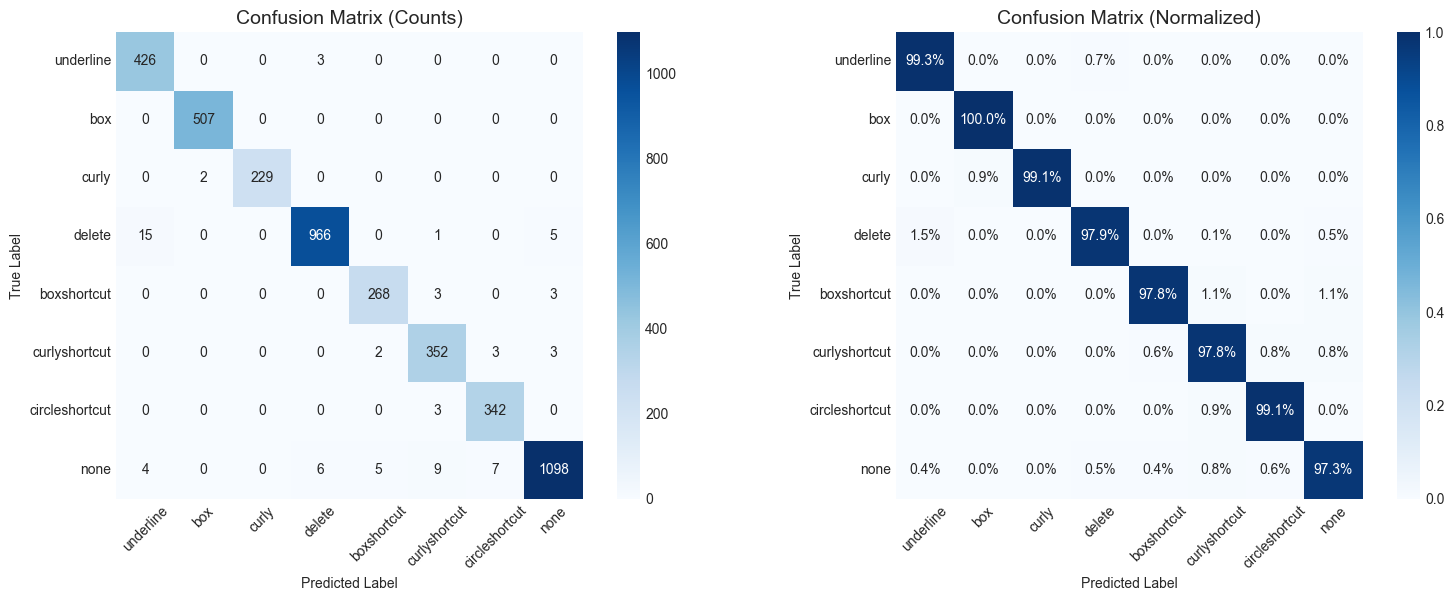

In [7]:
# Confusion matrix
y_test_true = splits['y_test'].astype(int)
cm = confusion_matrix(y_test_true, y_test_pred)
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[0], square=True)
axes[0].set_title('Confusion Matrix (Counts)', fontsize=14)
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')
axes[0].tick_params(axis='x', rotation=45)

# Normalized
sns.heatmap(cm_normalized, annot=True, fmt='.1%', cmap='Blues',
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            ax=axes[1], square=True)
axes[1].set_title('Confusion Matrix (Normalized)', fontsize=14)
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 6. Classification Report

In [8]:
print('Classification Report (Test Set)')
print('=' * 60)
print(classification_report(y_test_true, y_test_pred, target_names=CLASS_NAMES, zero_division=0))

Classification Report (Test Set)
                precision    recall  f1-score   support

     underline       0.96      0.99      0.97       429
           box       1.00      1.00      1.00       507
         curly       1.00      0.99      1.00       231
        delete       0.99      0.98      0.98       987
   boxshortcut       0.97      0.98      0.98       274
 curlyshortcut       0.96      0.98      0.97       360
circleshortcut       0.97      0.99      0.98       345
          none       0.99      0.97      0.98      1129

      accuracy                           0.98      4262
     macro avg       0.98      0.99      0.98      4262
  weighted avg       0.98      0.98      0.98      4262



## 7. Misclassified Samples

Display all samples where the model made incorrect predictions.

In [9]:
# Find misclassified indices
misclassified_mask = y_test_pred != y_test_true
misclassified_indices = np.where(misclassified_mask)[0]

print(f'Total test samples: {len(y_test_true)}')
print(f'Misclassified: {len(misclassified_indices)}')
print(f'Error rate: {len(misclassified_indices)/len(y_test_true)*100:.2f}%')

Total test samples: 4262
Misclassified: 74
Error rate: 1.74%


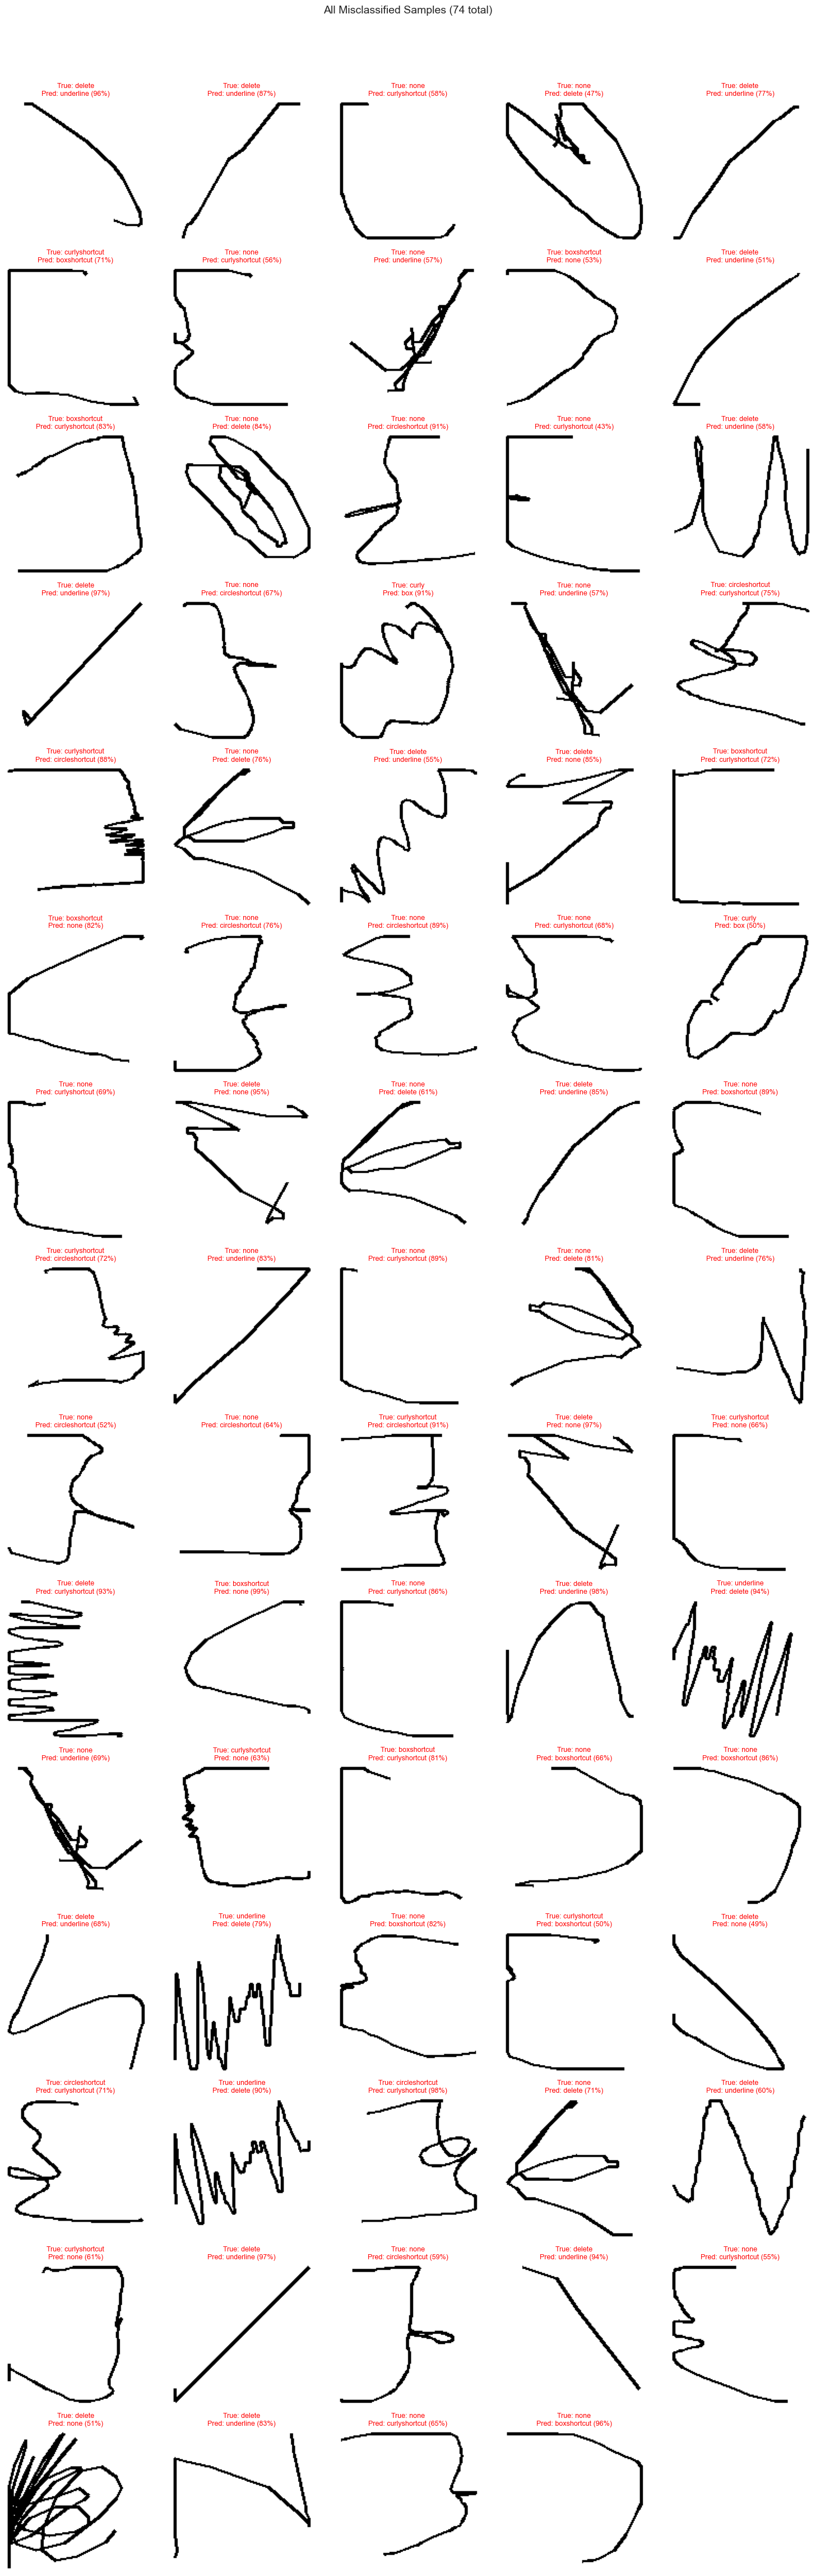

In [10]:
# Display all misclassified samples
if len(misclassified_indices) > 0:
    n_misclassified = len(misclassified_indices)
    cols = 5
    rows = (n_misclassified + cols - 1) // cols
    
    fig, axes = plt.subplots(rows, cols, figsize=(3*cols, 3*rows))
    axes = axes.flatten() if n_misclassified > 1 else [axes]
    
    for i, idx in enumerate(misclassified_indices):
        img = splits['X_test_img'][idx]
        true_label = CLASS_NAMES[y_test_true[idx]]
        pred_label = CLASS_NAMES[y_test_pred[idx]]
        confidence = y_test_probs[idx][y_test_pred[idx]] * 100
        
        # Handle both grayscale and RGB
        if img.shape[-1] == 1:
            axes[i].imshow(img.squeeze(), cmap='gray')
        else:
            axes[i].imshow(img)
        
        axes[i].set_title(f'True: {true_label}\nPred: {pred_label} ({confidence:.0f}%)', 
                          fontsize=9, color='red')
        axes[i].axis('off')
    
    # Hide unused subplots
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    
    plt.suptitle(f'All Misclassified Samples ({n_misclassified} total)', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()
else:
    print('🎉 No misclassified samples! Perfect accuracy on test set.')

## 8. Error Analysis by Class

Which classes are most commonly confused?

In [ ]:
if len(misclassified_indices) > 0:
    # Analyze confusion pairs
    confusion_pairs = []
    for idx in misclassified_indices:
        true = CLASS_NAMES[y_test_true[idx]]
        pred = CLASS_NAMES[y_test_pred[idx]]
        confusion_pairs.append(f'{true} → {pred}')
    
    from collections import Counter
    pair_counts = Counter(confusion_pairs)
    
    print('Most Common Misclassifications:')
    print('=' * 40)
    for pair, count in pair_counts.most_common(10):
        print(f'  {pair}: {count}')
else:
    print('No errors to analyze!')